# Relaciones entre variables

In [71]:
from proyecto_ciencia_de_datos.config import PROCESSED_DATA_DIR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

axa_df = pd.read_csv(PROCESSED_DATA_DIR / 'axa_EDA_son.csv', sep=',', header='infer', low_memory=False)
inegi_df = pd.read_csv(PROCESSED_DATA_DIR / 'inegi_EDA_son.csv', sep=',', header='infer')
weather_df = pd.read_csv(PROCESSED_DATA_DIR / 'weather_EDA_son.csv', sep=',', header='infer')

## AXA

Una matriz de correlacion para visualizar los valores numericos del dataset

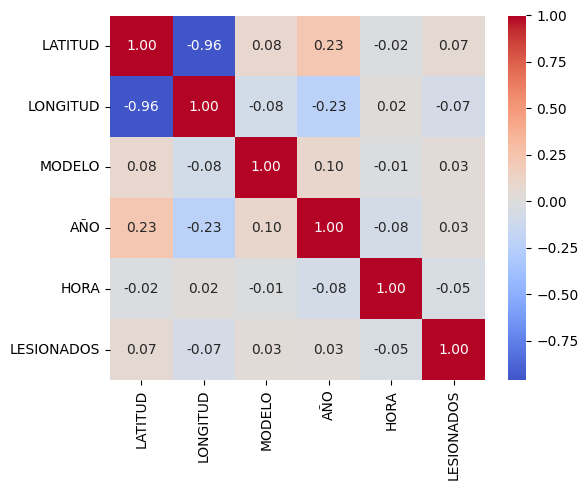

In [72]:
# Create correlation matrix for numerical columns
corr = axa_df[['LATITUD','LONGITUD','MODELO','AÑO','HORA','LESIONADOS']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.tight_layout()
plt.show()

### Visualizacion para las variables categoricas

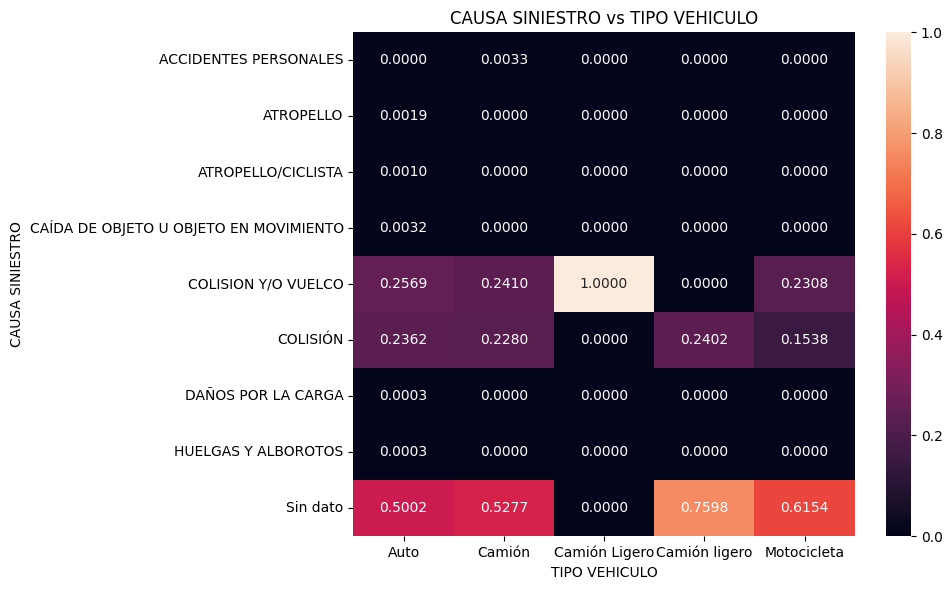

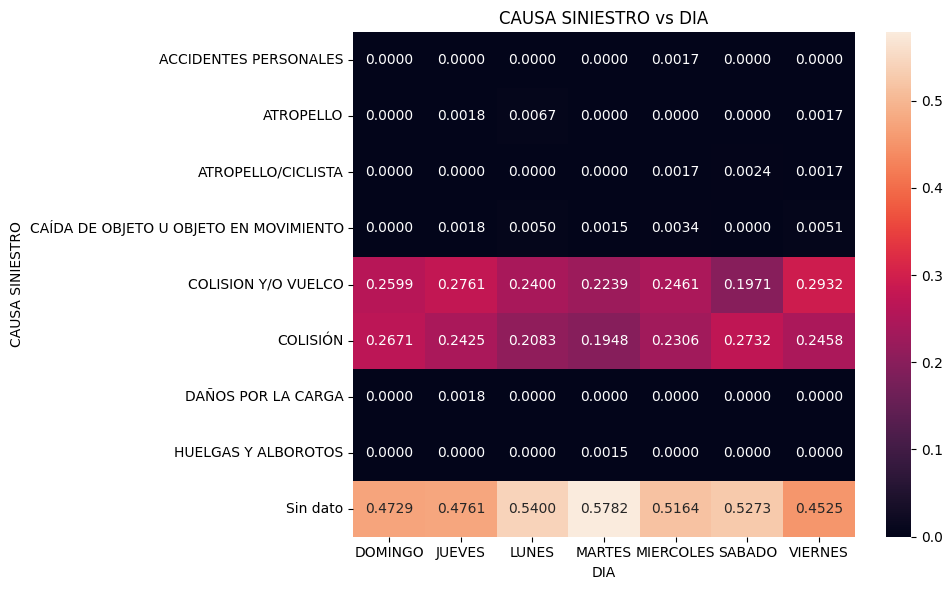

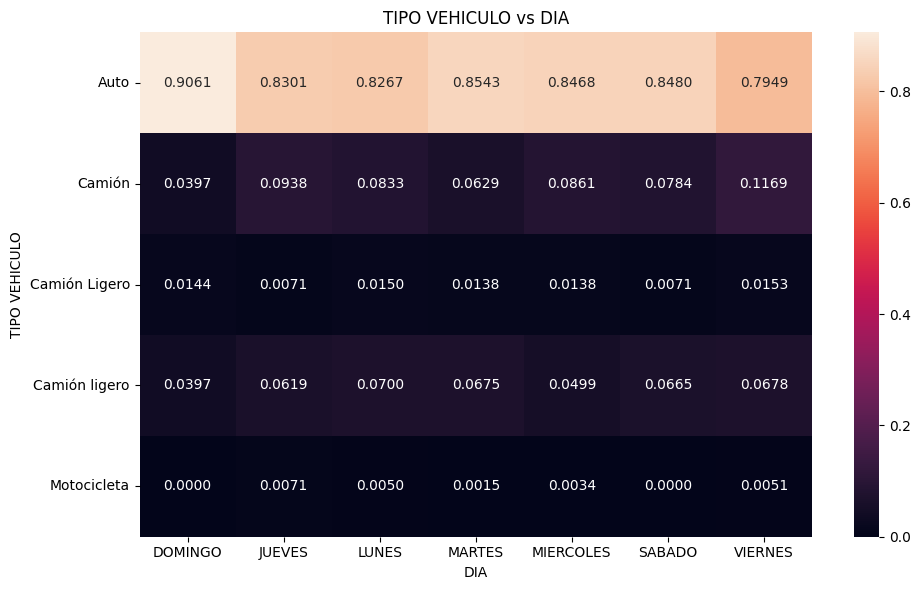

In [73]:
# Lista de columnas categóricas
cat_cols = ['CAUSA SINIESTRO', 'TIPO VEHICULO', 'DIA']
# Ciudad excluida por que no se ve bien en este tipo de grafico

# Generar combinaciones de dos columnas categóricas
pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        pairs.append((cat_cols[i], cat_cols[j]))

# Heatmaps
for col1, col2 in pairs:
    plt.figure(figsize=(10, 6))

    # Tabla de contingencia con categorías completas
    ct = pd.crosstab(
        axa_df[col1],
        axa_df[col2],
        dropna=False,
        normalize='columns'   # Normaliza por fila
    )

    sns.heatmap(ct, annot=True, fmt=".4f")
    plt.title(f"{col1} vs {col2}")
    plt.tight_layout()
    plt.show()


OBSERVACIONES:

Podemos observar que:
- Los accidentes más comunes en los datos de AXA son causados por **autos** personales (Por que tienen la mayor cantidad de conductores)
- El día con más accidentes es el **Martes**
- Los accidentes más comunes son **Colisión** y **Colisión Y/O Vuelco** (Excluyendo 'Sin Dato')

La mayoria de correlaciones son hacia los Autos, que pasa si vemos la correlacion sin ellos?

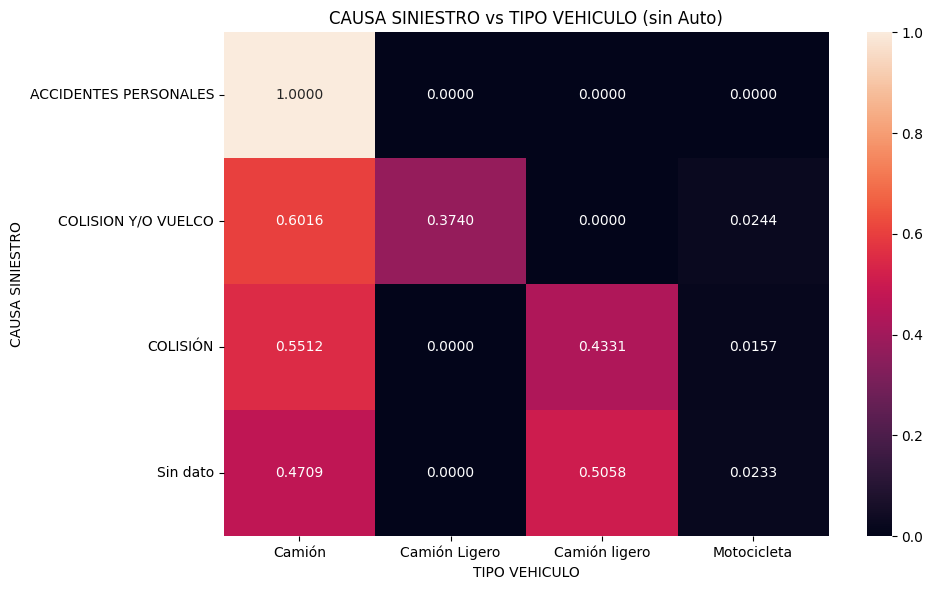

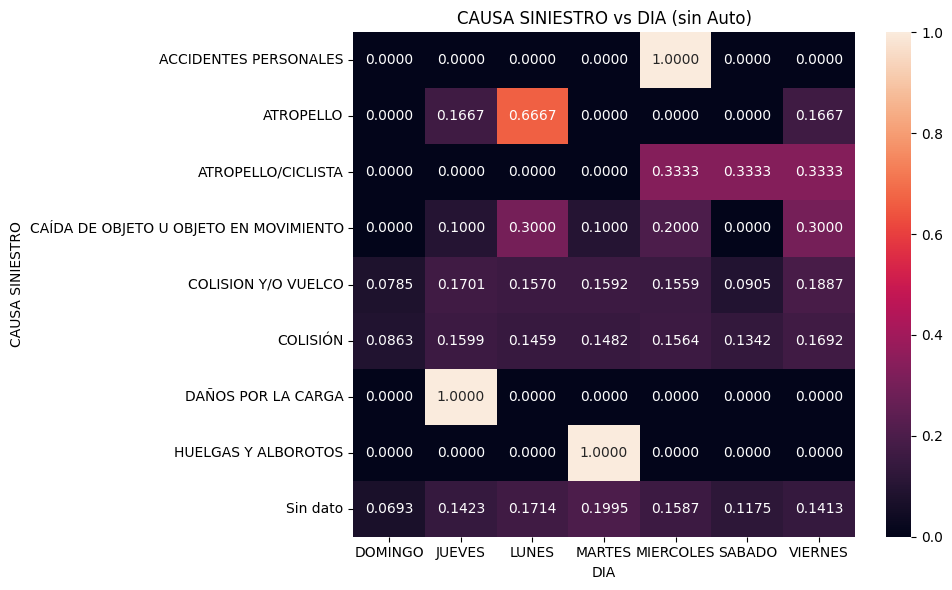

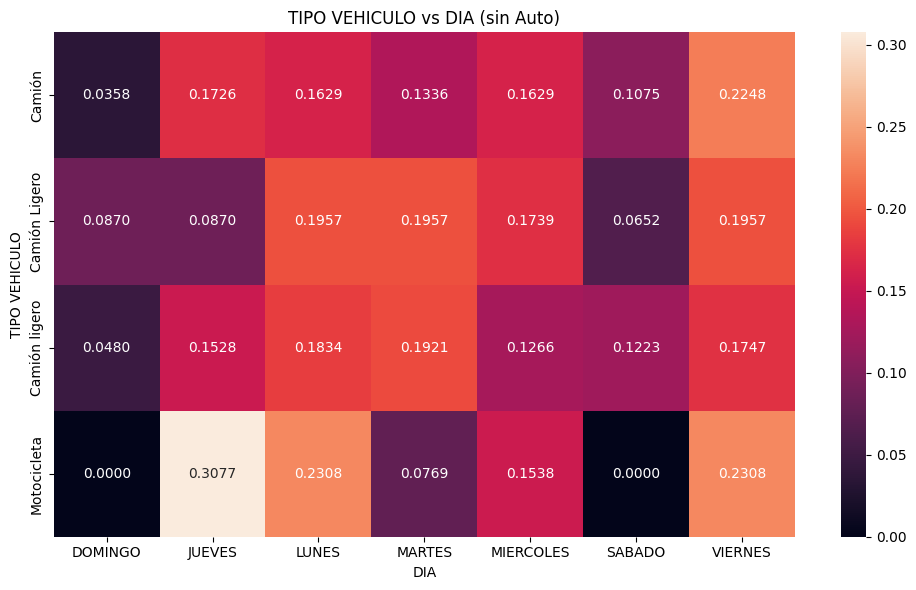

In [74]:
cat_cols = ['CAUSA SINIESTRO', 'TIPO VEHICULO', 'DIA']

# Generar pares
pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        pairs.append((cat_cols[i], cat_cols[j]))

for col1, col2 in pairs:
    # Copia filtrada solo para la gráfica actual
    df_plot = axa_df.copy()

    # Excluir "Auto" cuando TIPO VEHICULO aparece en cualquiera de las dos columnas
    if col1 == 'TIPO VEHICULO' or col2 == 'TIPO VEHICULO':
        df_plot = df_plot[df_plot['TIPO VEHICULO'] != 'Auto']

    # Tabla normalizada por fila
    ct = pd.crosstab(
        df_plot[col1],
        df_plot[col2],
        dropna=False,
        normalize='index'
    )

    # Eliminar filas/columnas de Auto si quedaron en el índice accidentalmente
    if 'Auto' in ct.index:
        ct = ct.drop(index='Auto')
    if 'Auto' in ct.columns:
        ct = ct.drop(columns='Auto')
        

    # Graficar
    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".4f")
    plt.title(f"{col1} vs {col2} (sin Auto)")
    plt.tight_layout()
    plt.show()


OBSERVACIONES
Al haber eliminado los autos personales de la grafica, podemos notar nuevas relaciones:

- Los accidentes más comunes en los datos de AXA son causados por *Camiones*
- Ahora ya no hay un día con más accidentes, ya que ahora se distribuye los dias con accidentes en una forma más general 
- Los accidentes más comunes ya no son **Colisión** y **Colisión Y/O Vuelco** pero ahora la cantidad de **'Sin Dato'** se reducío considerablemente, lo cual significa que la mayoria de estos son por **autos** personales
- Los accidentes **Personales** parecen ser causados solamente por **Camión** y solo el **Miercoles**, esto puede ser por que no muchos accidentes son marcados como **Personales** o son registrados como **'Sin Dato'**

## INEGI

### Observando relaciones con tipo de accidente

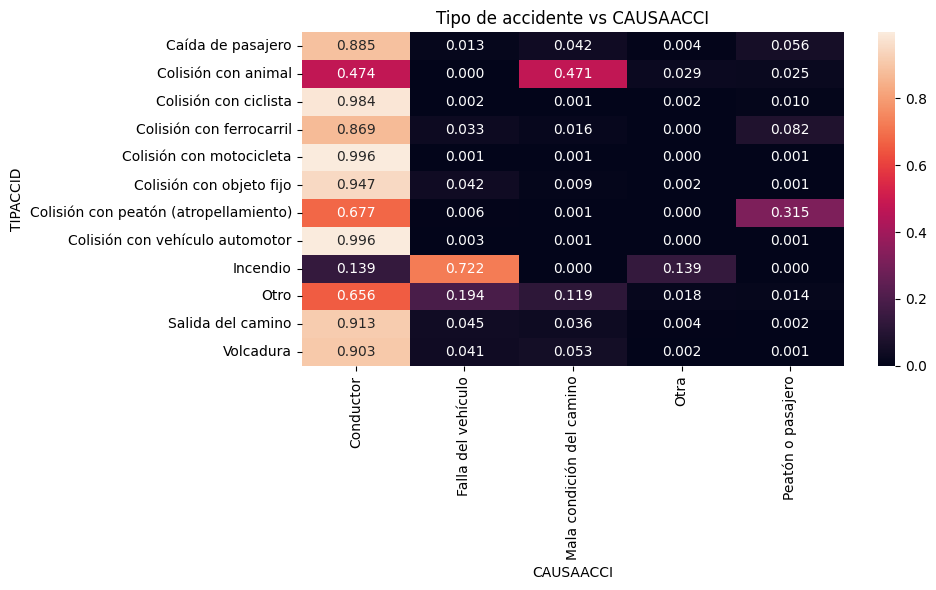

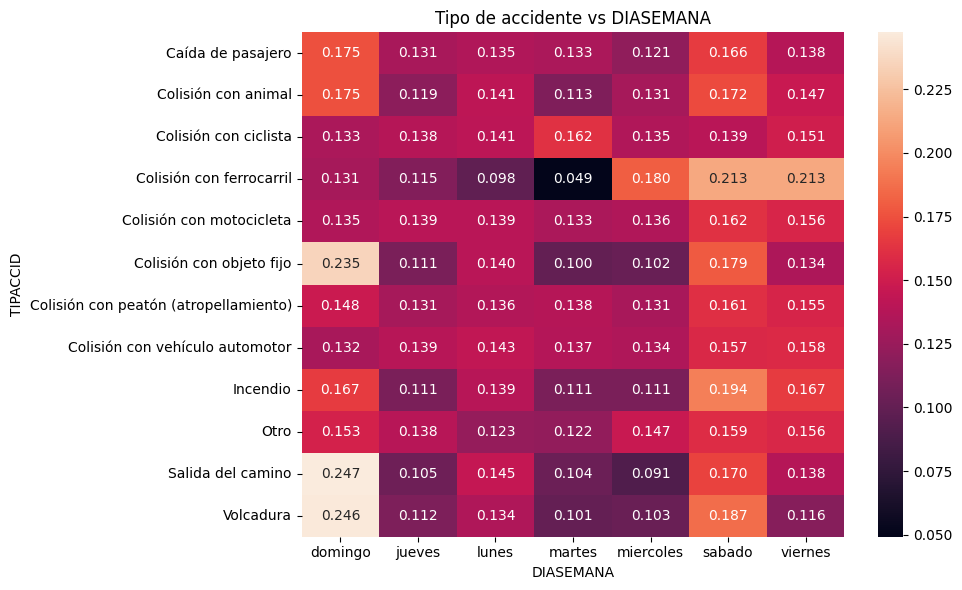

In [75]:
# Columnas categóricas importantes
cat_cols = [
    'CAUSAACCI',
    'DIASEMANA'
]

# Heatmaps
for col in cat_cols:

    ct = pd.crosstab(
        inegi_df['TIPACCID'],
        inegi_df[col],
        dropna=True,
        normalize='index'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Tipo de accidente vs {col}")
    plt.tight_layout()
    plt.show()


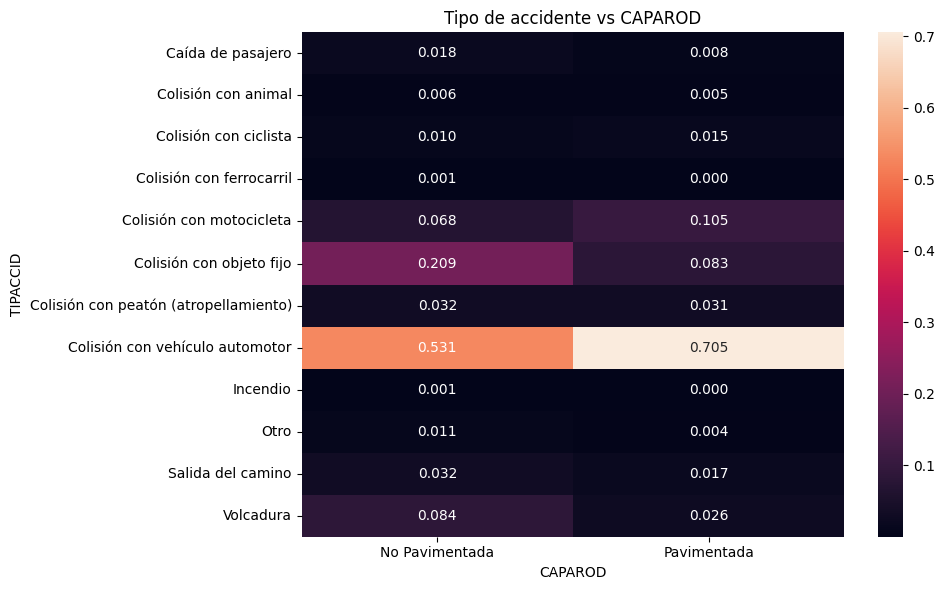

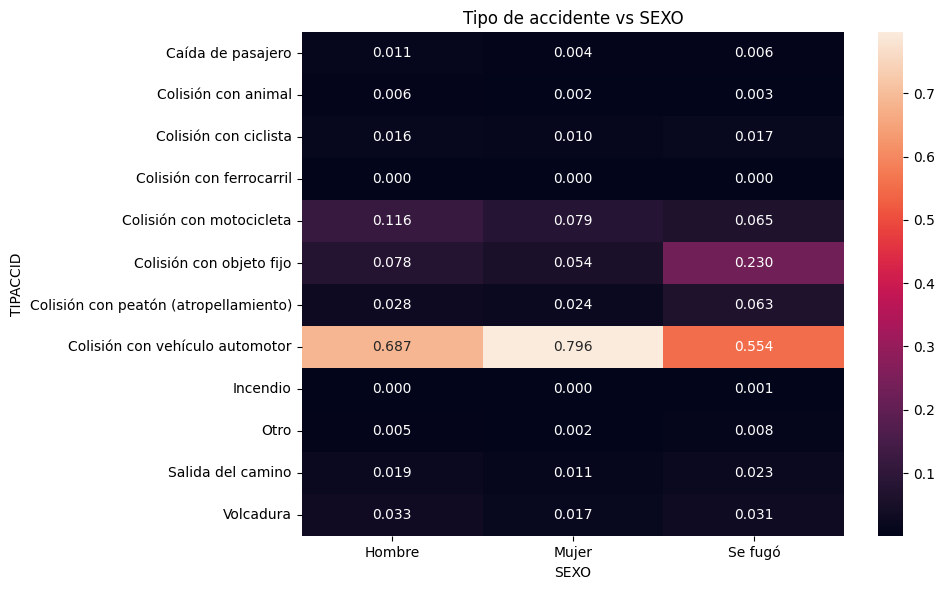

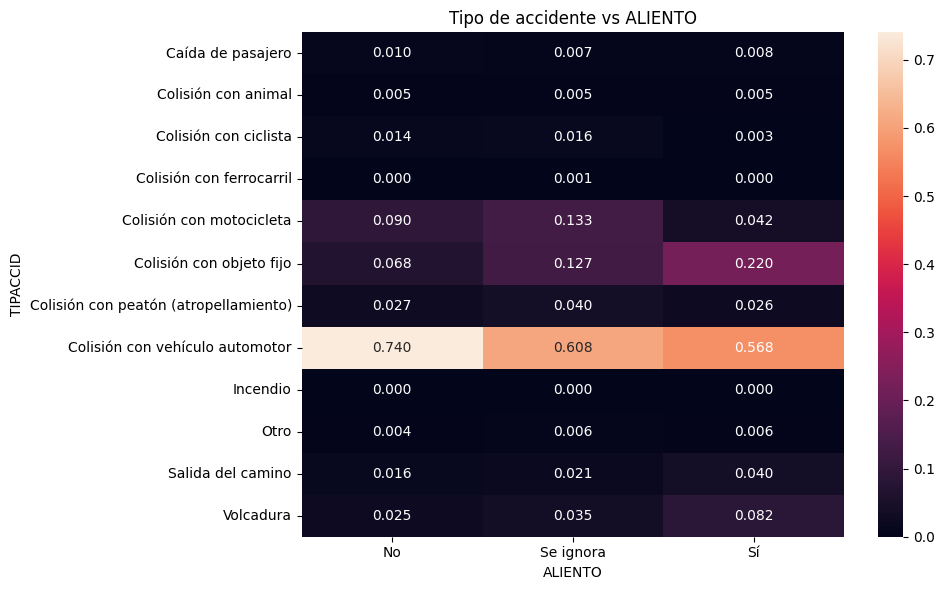

In [76]:
cat_cols2 = [
    'CAPAROD',
    'SEXO',
    'ALIENTO'
]
# Heatmaps
for col in cat_cols2:

    ct = pd.crosstab(
        inegi_df['TIPACCID'],
        inegi_df[col],
        dropna=True,
        normalize='columns'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Tipo de accidente vs {col}")
    plt.tight_layout()
    plt.show()


In [77]:
inegi_df['CAPAROD'].value_counts()

CAPAROD
Pavimentada       133451
No Pavimentada      9190
Name: count, dtype: int64

In [78]:
inegi_df['SEXO'].value_counts()

SEXO
Hombre     95373
Mujer      30157
Se fugó    17111
Name: count, dtype: int64

In [79]:
inegi_df['ALIENTO'].value_counts() 

ALIENTO
No           93920
Se ignora    45173
Sí            3548
Name: count, dtype: int64

#### Observaciones del tipo de accidente:

- Causa de Accidente:
    - La mayoria de accidentes son por culpa del conductor, excepto:
        - **Incendios**, los cuales son por falla del vehiculo
        - **Colision con Animal**, los cuales son en parte por la mala condición del camino
        - **Atropellamiento**, los cuales son en parte por que un **pasajero o peaton** que distraen al conductor
- Dia de la Semana:
    - El martes tiene la menor cantidad de accidentes con **ferrocarriles** pero viernes y sabado tienen más que el resto de días
    - El domingo especificamente tiene una mayor cantidad de accidentes de tipo:
        - Colisión con objeto fijo
        - Salida del camino
        - Volcadura

Algunas variables no se lograban apreciar las diferencias, asi que las normalizamos con base a la columna en lugar del accidente:

- Calle Pavimentada:
    - La mayoria sucede en pavimentada pero esto es por la proporcion de accidentes en cada tipo
    - La colisión con objetos fijos sucede mayoritariamente en calles no pavimentadas
    - Las volcaduras son más comunes en calles no pavimentadas

- Sexo:
    - Los accidentes más comunes para los 2 sexos y los que se fugan es **Colisión con Vehiculo Automotor**
        - Las mujeres tienen una mayor proporción de este tipo de accidente comparado a los hombres y que se fugan
    - Cuando es **Colisión con Objeto Fijo** es más probable que se fuge el culpable
    - Los hombres tienen más colisiones con **Motocicleta**
    
- Aliento:
    - La gran mayoria de accidentes son causados por gente sin aliento alcoholico o se ignora por completo
    - Cuando es **Colisión con Objeto Fijo** es más probable que tengan aliento alcoholico

### Observando relaciones con causa de accidente


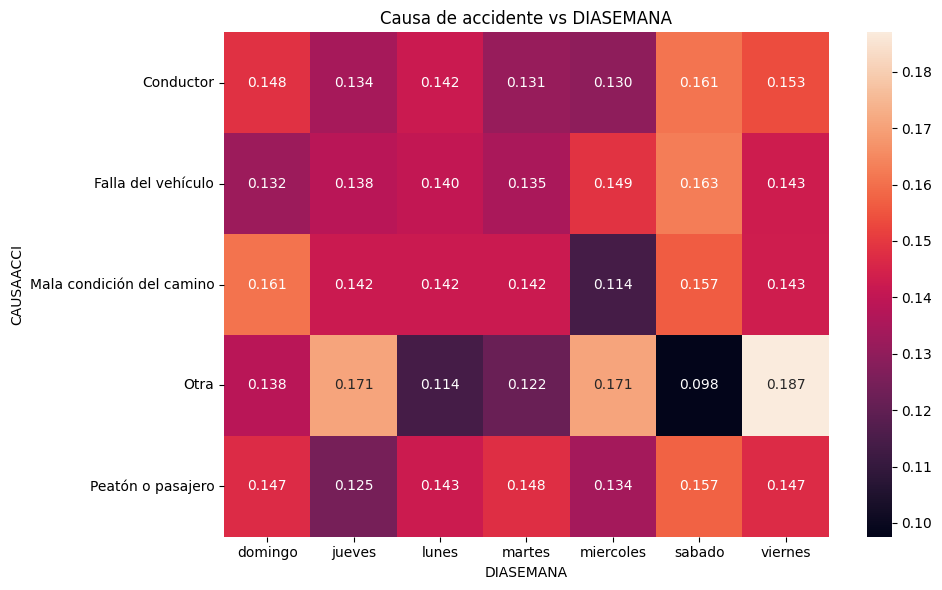

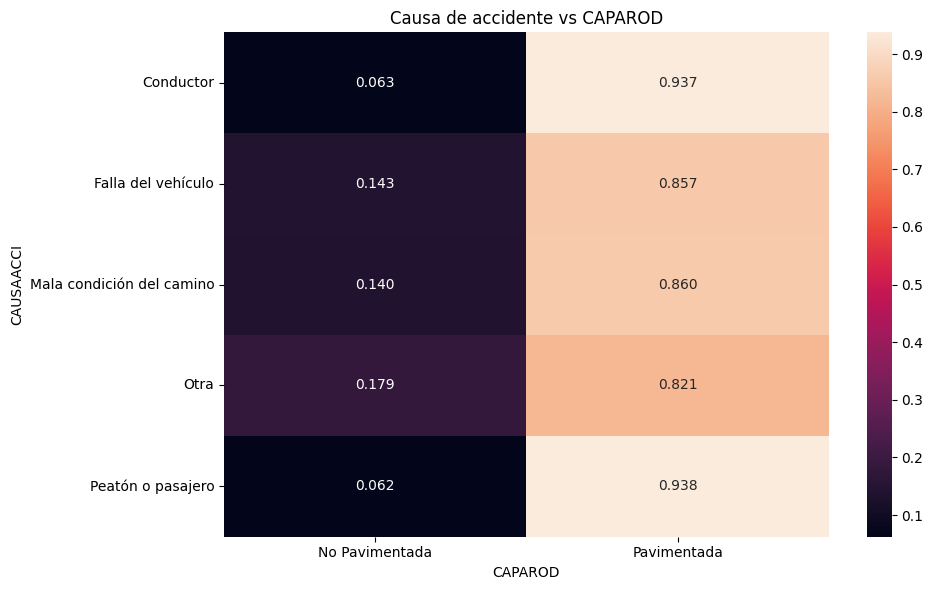

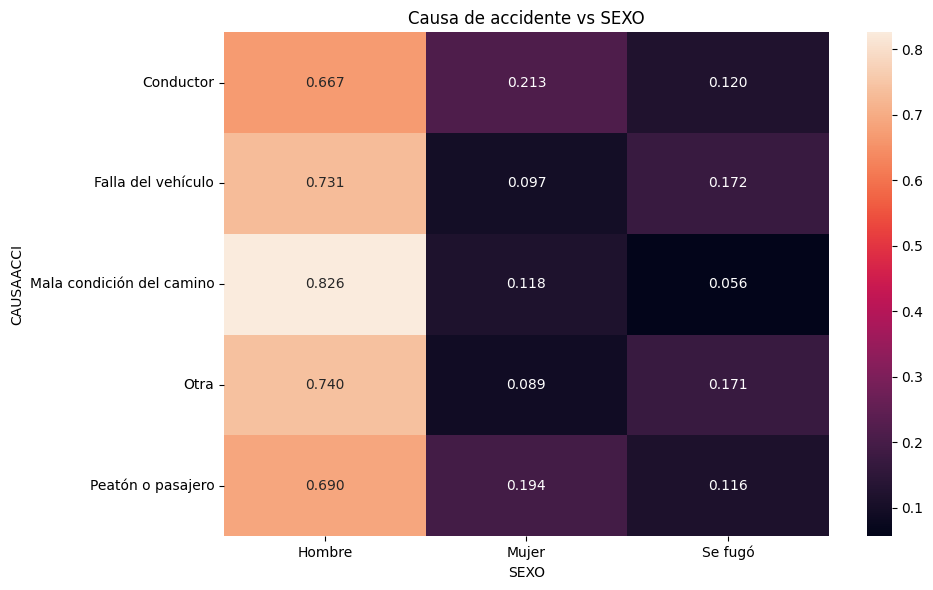

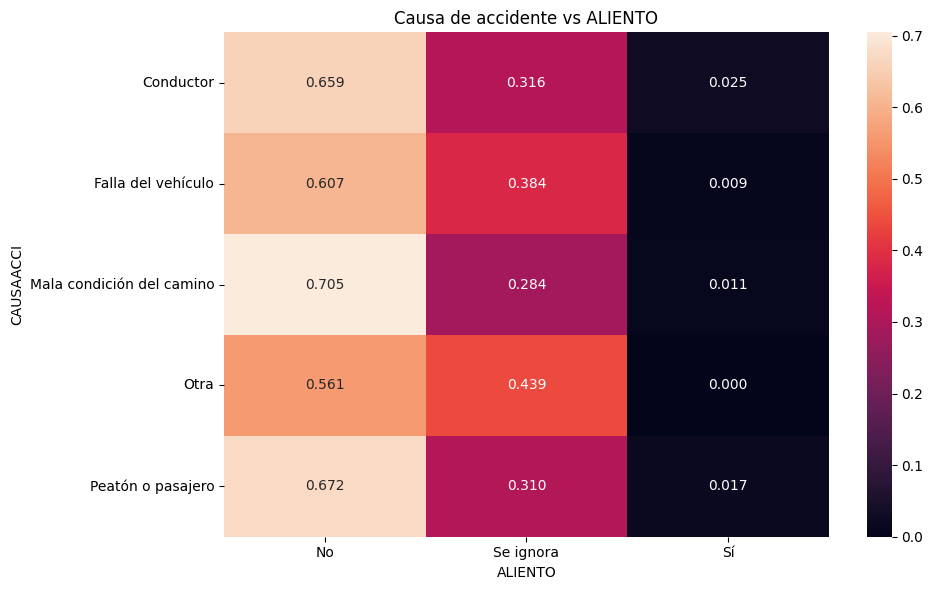

In [80]:
# Columnas categóricas importantes
cat_cols3 = [
    'DIASEMANA',
    'CAPAROD',
    'SEXO',
    'ALIENTO'
]

# Heatmaps
for col in cat_cols3:

    ct = pd.crosstab(
        inegi_df['CAUSAACCI'],
        inegi_df[col],
        dropna=True,
        normalize='index'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Causa de accidente vs {col}")
    plt.tight_layout()
    plt.show()


In [81]:
inegi_df['CAUSAACCI'].value_counts()

CAUSAACCI
Conductor                    138601
Peatón o pasajero              1620
Falla del vehículo             1339
Mala condición del camino       958
Otra                            123
Name: count, dtype: int64

#### Observaciones de la causa de accidente:

- Dia de la Semana:
    - El viernes especificamente tiene una mayor causa de accidentes de tipo **Otra**
    - El sabado tiene menor mayor causa de accidentes tipo **Otra** pero más de **Falla de Vehiculo** y **Conductor** que otros días 

- Sexo:
    - La causa de accidentes más comunes para cada sexo es:
        - Mujeres: **Conductor**
        - Hombres: **Mala Condición del Camino**
        - Fugó: **Falla del Vehiculo** y **Otra**
    
- Aliento:
    - La mayor causa de accidentes de cada tipo de aliento son:
        - No: **Mala condicion del Camino**
        - Se ignora: **Otra**
        - Si: **Conductor**

Esta vez no cambiamos el tipo de normalización por que la mayoria son por culpa del conductor y esto no permite observar las demás variables.

### Comparacion de Causa y Tipo de Accidente con tipo de Vehiculo 

In [94]:
print((inegi_df['AUTOMOVIL'] > 0).sum())
print((inegi_df['AUTOMOVIL'] == 0).sum())

119971
22670


Como la mayoria de registros son de Automovil, los vamos a revisar por separado

#### Causa (Enfocado a Automovil)

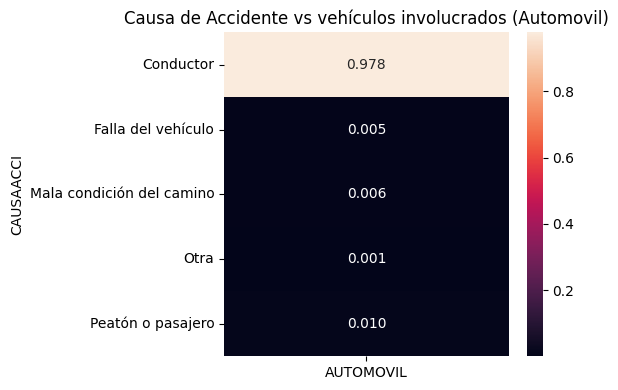

In [100]:
veh_cols = [
    'AUTOMOVIL'
]

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(6, 4))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['CAUSAACCI'],
        veh_bin_df[col],
        normalize='columns'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Causa de Accidente vs vehículos involucrados (Automovil)")
plt.tight_layout()
plt.show()

Observaciones:
Podemos ver que la mayor causa de accidentes es por culpa del conductor por  una gran mayoria

#### Tipo (Enfocado a Automovil)

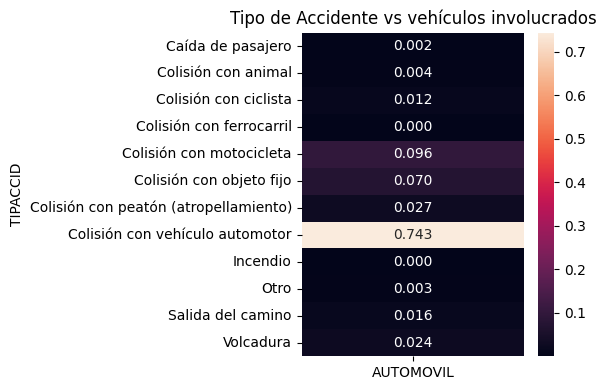

In [103]:
# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(6, 4))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['TIPACCID'],
        veh_bin_df[col],
        normalize='columns'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Tipo de Accidente vs vehículos involucrados")
plt.tight_layout()
plt.show()


Observaciones:

El mayor tipo de accidente es por **Colision con vehiculo automotor**, seguido por **Colisión con motocicleta** aunque la diferencia es muy grande.

#### Omitiendo Automovil

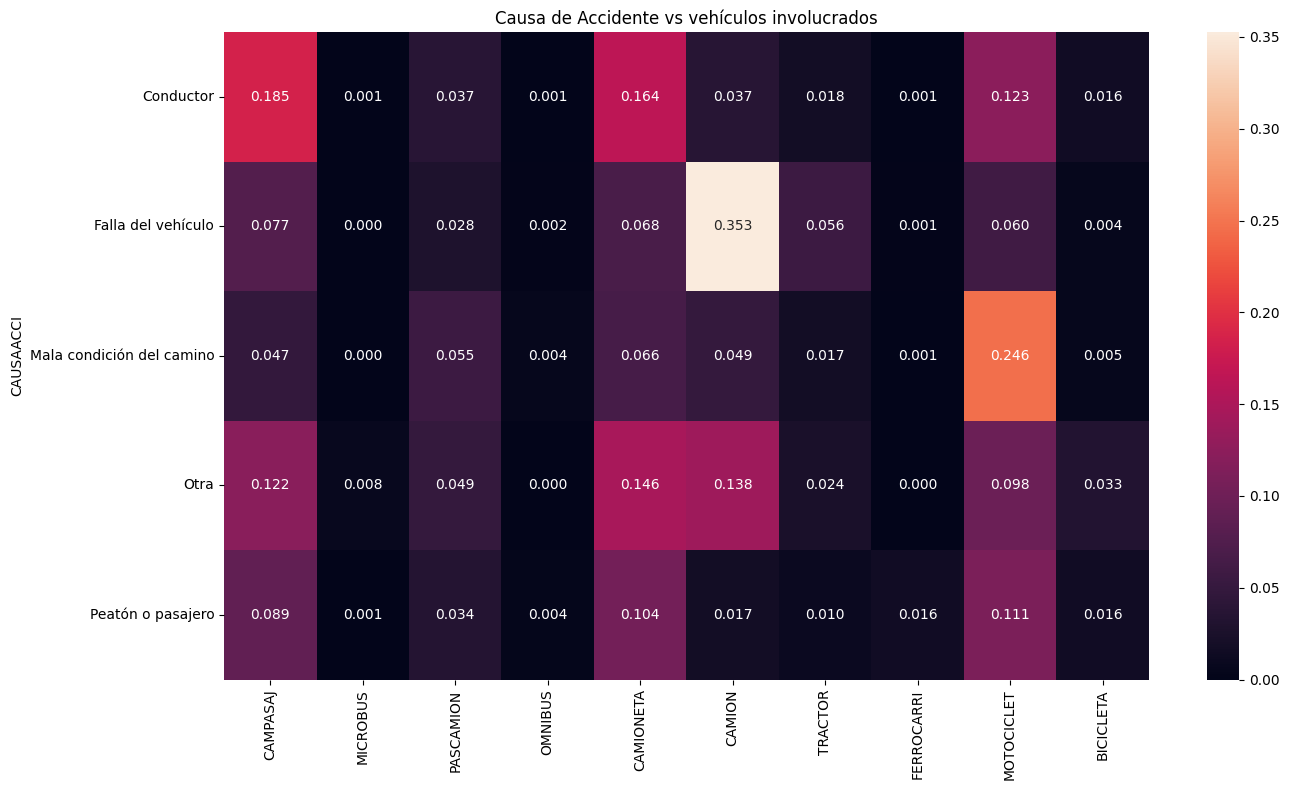

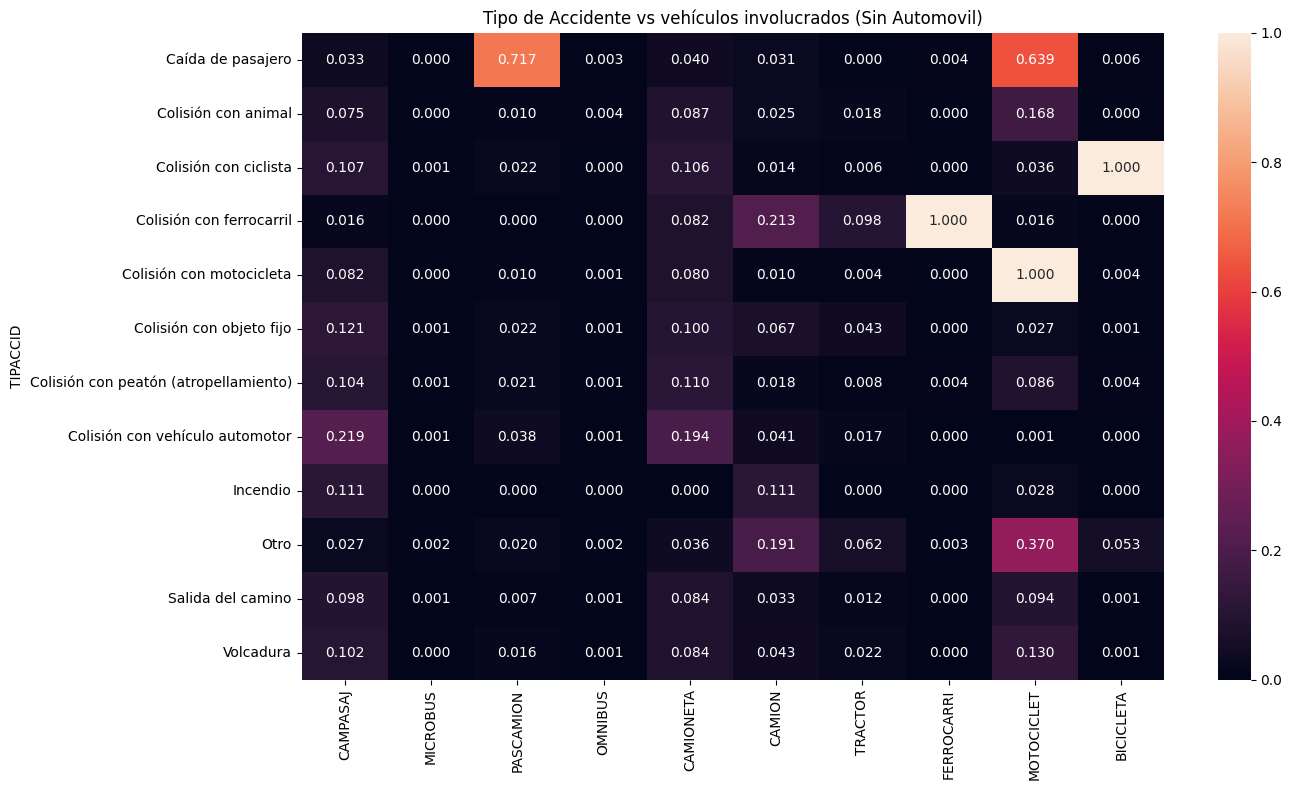

In [105]:
veh_cols = [
    'CAMPASAJ','MICROBUS','PASCAMION','OMNIBUS',
    'CAMIONETA','CAMION','TRACTOR','FERROCARRI','MOTOCICLET','BICICLETA'
]

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['CAUSAACCI'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Causa de Accidente vs vehículos involucrados")
plt.tight_layout()
plt.show()

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['TIPACCID'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Tipo de Accidente vs vehículos involucrados (Sin Automovil)")
plt.tight_layout()
plt.show()


#### Observaciones:
- Causa de Accidentes:
    - Los vehiculos que tienen más accidentes causados por el conductor son:
        - Camion de Pasajeros
        - Camioneta
        - Motocicleta
    - En falla de vehiculo, la mayoria son por:
        - Camion (De carga)
    - Por mala condicion del camino es:
        - Motocicleta
    - Por otro:
        - Camion de Pasajeros
        - Camioneta
        - Motocicleta
        - Camion (De carga)
    - Por culpa del pasajero o peaton:
        - Camion de Pasajeros
        - Camioneta
        - Motocicleta
    - Los vehiculos con la menor cantidad de accidentes son el Mircobus, Omnibus, Ferrocarril y Bicicleta

- Tipo de Accidente:
    - En caida de Pasajero, la mayoria estan dadas por:
        - Camion de Pasajeros
        - Motocicleta
    - En otro solo resalta el vehiculo:
        - Motocicleta
        
    - Hay algunos vehiculos que tienen 1.0 en su valor pero es por que el tipo de accidente involucra el vehiculo en especifico.